In [88]:
import cv2
import numpy as np

# Lista de colores HSV proporcionada
hsv_colors = [
    (0.0, 0.95, 1), (0.125, 0.95, 1), (0.25, 0.95, 1), (0.375, 0.95, 1),
    (0.5, 0.95, 1), (0.625, 0.95, 1), (0.75, 0.95, 1), (0.875, 0.95, 1),
    (0.041666666666666664, 0.85, 0.5), (0.16666666666666666, 0.85, 0.5),
    (0.2916666666666667, 0.85, 0.5), (0.4166666666666667, 0.85, 0.5),
    (0.5416666666666666, 0.85, 0.5), (0.6666666666666666, 0.85, 0.5),
    (0.7916666666666666, 0.85, 0.5), (0.9166666666666666, 0.85, 0.5),
    (0.08333333333333333, 0.75, 0.3), (0.20833333333333334, 0.75, 0.3),
    (0.3333333333333333, 0.75, 0.3), (0.4583333333333333, 0.75, 0.3),
    (0.5833333333333334, 0.75, 0.3), (0.7083333333333334, 0.75, 0.3)
]

# Convertir HSV de [0-1] a [0-179, 0-255, 0-255]
hsv_colors_cv = [(int(h * 179), int(s * 255), int(v * 255)) for h, s, v in hsv_colors]

def extract_classes_from_mask(mask_path, hsv_colors_cv):
    # Cargar la imagen y convertirla a HSV
    mask = cv2.imread(mask_path)
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    # Aplicar procesamiento para definir mejor las regiones de las máscaras
    mask_rgb = cv2.GaussianBlur(mask_rgb, (5, 5), 0)  # Suavizado para reducir ruido
    mask_rgb = cv2.medianBlur(mask_rgb, 9)  # Mediana para eliminar píxeles espurios

    hsv = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2HSV)

    # Inicializar matriz de salida [X, Y, 22]
    height, width = hsv.shape[:2]
    class_matrix = np.zeros((height, width, len(hsv_colors_cv)), dtype=np.uint8)

    # Crear máscaras para cada clase basada en el color
    for i, (h, s, v) in enumerate(hsv_colors_cv):
        # Definir rangos HSV para detectar la clase
        lower = np.array([max(h - 10, 0), max(s - 200, 0), max(v - 51, 0)])
        upper = np.array([min(h + 10, 179), min(s + 200, 255), min(v + 51, 255)])
        
        # Generar máscara binaria
        mask_class = cv2.inRange(hsv, lower, upper)
        class_matrix[:, :, i] = mask_class // 255  # Convertir a binario (0 o 1)
        class_matrix[:, :, i] = np.where(mask_class > 0, 1, 0)  # Binario estricto
    return class_matrix,mask_rgb


# Uso del algoritmo
mask_path = r'C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask\2750.png'  # Reemplaza con tu ruta de imagen
result_matrix,mask = extract_classes_from_mask(mask_path, hsv_colors_cv)

print(f"Matrix de segmentación generada con dimensiones: {result_matrix.shape}")

Matrix de segmentación generada con dimensiones: (1080, 1920, 22)


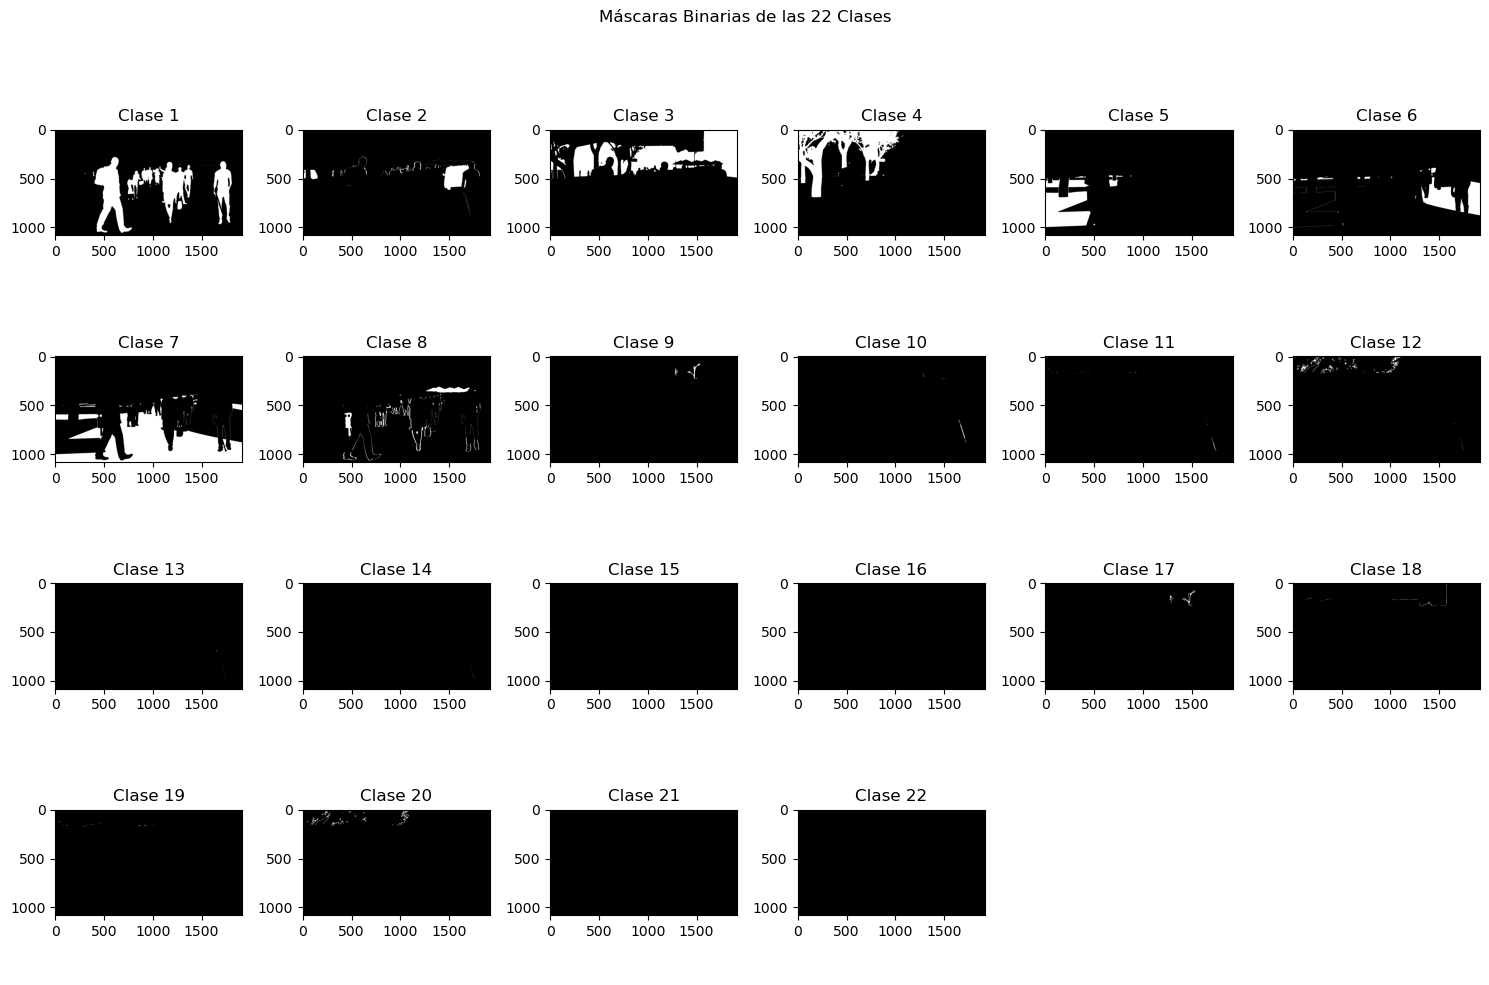

In [89]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
fig.suptitle('Máscaras Binarias de las 22 Clases')

for i, ax in enumerate(axes.flat):
    if i < 22:
        ax.imshow(result_matrix[:, :, i], cmap='gray')
        ax.set_title(f'Clase {i+1}')
    else:
        ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

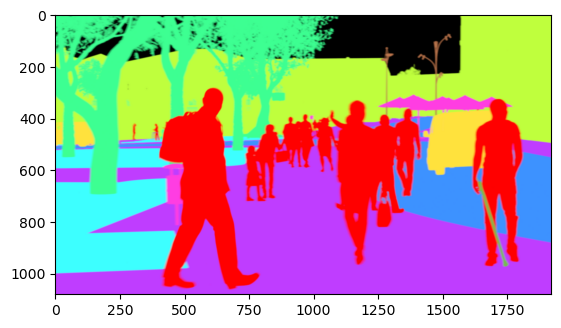

In [76]:
plt.imshow(mask)

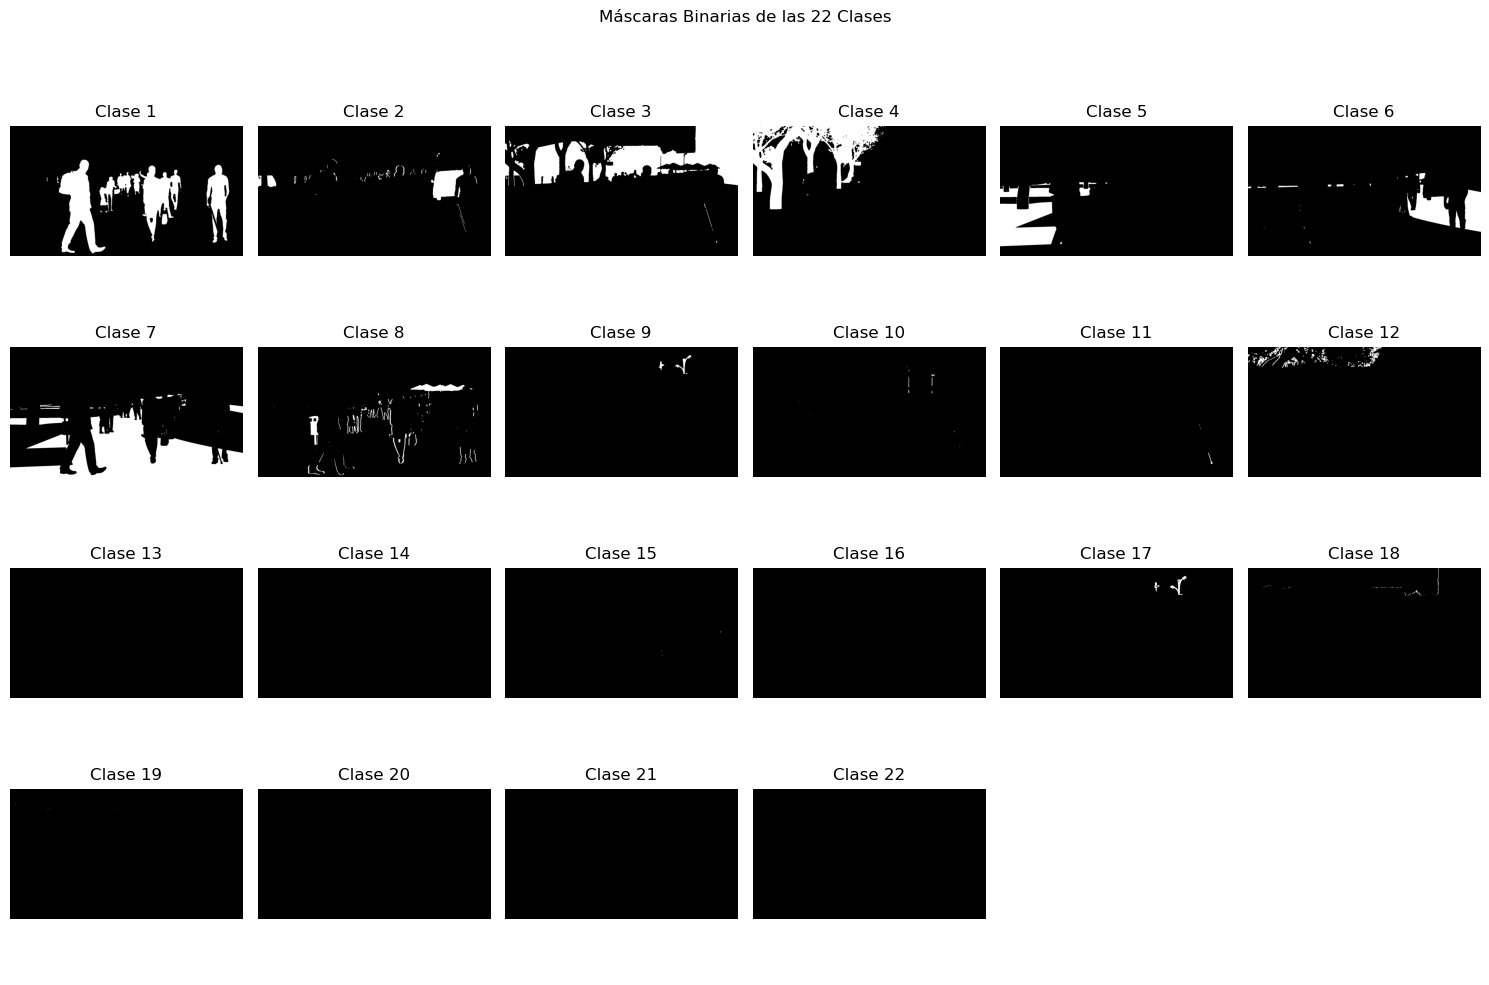

In [92]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Lista de colores HSV proporcionada
hsv_colors = [
    (0.0, 0.95, 1), (0.125, 0.95, 1), (0.25, 0.95, 1), (0.375, 0.95, 1),
    (0.5, 0.95, 1), (0.625, 0.95, 1), (0.75, 0.95, 1), (0.875, 0.95, 1),
    (0.041666666666666664, 0.85, 0.5), (0.16666666666666666, 0.85, 0.5),
    (0.2916666666666667, 0.85, 0.5), (0.4166666666666667, 0.85, 0.5),
    (0.5416666666666666, 0.85, 0.5), (0.6666666666666666, 0.85, 0.5),
    (0.7916666666666666, 0.85, 0.5), (0.9166666666666666, 0.85, 0.5),
    (0.08333333333333333, 0.75, 0.3), (0.20833333333333334, 0.75, 0.3),
    (0.3333333333333333, 0.75, 0.3), (0.4583333333333333, 0.75, 0.3),
    (0.5833333333333334, 0.75, 0.3), (0.7083333333333334, 0.75, 0.3)
]

# Convertir HSV de [0-1] a [0-179, 0-255, 0-255]
hsv_colors_cv = [(int(h * 179), int(s * 255), int(v * 255)) for h, s, v in hsv_colors]

def extract_classes_from_rgb_mask(mask_path, hsv_colors_cv):
    # Leer la imagen como RGB (no BGR)
    mask = cv2.imread(mask_path)
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    # Aplicar procesamiento para definir mejor las regiones de las máscaras
    mask_rgb = cv2.GaussianBlur(mask_rgb, (5, 5), 0)  # Suavizado para reducir ruido
    mask_rgb = cv2.medianBlur(mask_rgb, 5)  # Mediana para eliminar píxeles espurios

    # Ajustar colores predominantes para cada máscara
    hsv = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2HSV)
    for i, (h, s, v) in enumerate(hsv_colors_cv):
        lower = np.array([max(h - 10, 0), max(s - 200, 0), max(v - 51, 0)])
        upper = np.array([min(h + 10, 179), min(s + 200, 255), min(v + 51, 255)])
        mask_class = cv2.inRange(hsv, lower, upper)

        # Calcular el color predominante
        mask_indices = np.where(mask_class > 0)
        if len(mask_indices[0]) > 0:
            mean_hue = int(np.mean(hsv[mask_indices][:, 0]))
            mean_sat = int(np.mean(hsv[mask_indices][:, 1]))
            mean_val = int(np.mean(hsv[mask_indices][:, 2]))

            # Asignar el color predominante a los píxeles de la máscara
            hsv[mask_indices] = (mean_hue, mean_sat, mean_val)

    # Reconstruir la imagen después del ajuste
    mask_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    # Volver a segmentar las clases con colores ajustados
    hsv = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2HSV)
    height, width = hsv.shape[:2]
    class_matrix = np.zeros((height, width, len(hsv_colors_cv)), dtype=np.uint8)

    # Crear máscaras para cada clase basada en el color ajustado
    for i, (h, s, v) in enumerate(hsv_colors_cv):
        lower = np.array([max(h - 5, 0), max(s - 200, 0), max(v - 80, 0)])
        upper = np.array([min(h + 5, 179), min(s + 200, 255), min(v + 80, 255)])
        mask_class = cv2.inRange(hsv, lower, upper)
        mask_class = cv2.morphologyEx(mask_class, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
        mask_class = cv2.morphologyEx(mask_class, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
        class_matrix[:, :, i] = np.where(mask_class > 0, 1, 0)

    return class_matrix

# Extraer la matriz de clases
mask_path = r'C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask\2750.png'  # Reemplaza con tu ruta de imagen
result_matrix = extract_classes_from_rgb_mask(mask_path, hsv_colors_cv)

# Mostrar las 22 clases en un subplot
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
fig.suptitle('Máscaras Binarias de las 22 Clases')

for i, ax in enumerate(axes.flat):
    if i < 22:
        ax.imshow(result_matrix[:, :, i], cmap='gray')
        ax.set_title(f'Clase {i+1}')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()
